# Full pipeline, end to end, from Jupyter

This notebook does **everything the repository's command-line workflow does**, in the same
order, by calling the same functions the CLI entry points call. Each section shows the
equivalent shell command, explains what the stage does, then runs it.

| # | Stage | CLI equivalent |
|---|-------|----------------|
| 0 | Setup | `conda activate bsl` |
| 1 | Check availability / download clips | `python -m src.download [--dry-run]` |
| 2 | Extract landmarks | `python -m src.extract --videos data/raw_videos --out data/landmarks` |
| 3 | Inspect a cached clip (105-landmark layout) | — |
| 4 | Preprocessing: gap fill → normalise → NaN→0 → resample | — |
| 5 | Dataset summary + organisation-grouped splits | `python -m src.dataset --summary --make-splits` |
| 6 | `BSLDataset` + a training batch | — |
| 7 | Augmentation + visual sanity check | `python scripts/plot_augmentations.py` |
| 8 | Models + parameter counts | `python -m src.models` |
| 9 | Regenerate the 12 experiment configs | `python configs/gen_configs.py` |
| 10 | Sanity checks (overfit one batch, label shuffle) | `python -m src.train ... --overfit-batch / --shuffle-labels` |
| 11 | Train (one run, or the full 12-run grid) | `python -m src.train --config configs/<cfg>.yaml` |
| 12 | LR / weight-decay grid | `python scripts/run_lr_grid.py` |
| 13 | Evaluate + McNemar's test | `python -m src.evaluate --checkpoint ... --split val` |
| 14 | Latency benchmark | `python -m src.benchmark --checkpoint ... --synthetic` |
| 15 | Real-time webcam demo | `python -m src.realtime --checkpoint ...` |
| 16 | Gradio demo app | `python app/app.py` |
| 17 | Test suite | `pytest` |

Long-running or destructive cells are guarded by flags (`RUN_FULL_GRID`, `RUN_TEST_EVAL`, ...)
that default to off, so the notebook can safely be run top to bottom.

Environment: the `bsl` conda env from the README (`python 3.11`, `pip install -r requirements.txt`).
MediaPipe is only needed for sections 1–2 and 15–16; everything else runs from the cached
landmarks already in `data/landmarks/`.


## 0 — Setup

All repository code uses paths relative to the repo root (`data/...`, `configs/...`,
`results/...`), so the working directory is changed to the repository root and the root is placed on `sys.path`
(the notebook lives in `notebooks/`, one level down).

In [1]:
import os
import sys
from pathlib import Path

# Walk up from the notebook's directory until the repo root (the folder with src/) is found.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Could not find the repository root (no src/ directory above cwd)")
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("working directory:", Path.cwd())


working directory: C:\Users\shamr\Downloads\Claude\MSc Project\CODE\bsl-word-transformer


In [2]:
import json

# torch is imported before pandas/scipy/sklearn on purpose: with a CUDA torch build on
# Windows, importing it after those packages can fail DLL initialisation (WinError 1114).
import torch

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

print("python :", sys.version.split()[0])
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("torch  :", torch.__version__, "| cuda available:", torch.cuda.is_available())


python : 3.13.9
numpy  : 2.3.5
pandas : 2.3.3
torch  : 2.11.0+cu128 | cuda available: True


## 1 — Check availability and download clips

CLI: `python -m src.download --dry-run` then `python -m src.download`

`src/download.py` is a **polite scraper** for SignBSL.com: one identifying user agent, at
least 1 second between HTTP requests, and it is **idempotent** — any source URL already in
`data/metadata.csv` is skipped, so re-running it never re-downloads anything. Videos land in
`data/raw_videos/{word}/{clip_id}.mp4` and one metadata row is appended (and persisted)
per clip. Downloaded videos are for local research use only and are never redistributed.

`main()` accepts an argv list, so it is invoked exactly as the CLI invokes it. A dry run prints
per-word variant counts and writes nothing.

In [3]:
vocabulary = pd.read_csv("data/vocabulary.csv")
print(f"{len(vocabulary)} vocabulary words")
vocabulary.head()


50 vocabulary words


,word,category,handedness,notes
0,hello,greetings-courtesy,one,open hand raised near head with small wave
1,goodbye,greetings-courtesy,one,open hand waving side to side
2,please,greetings-courtesy,one,flat hand at chin moving slowly forward and do...
3,thank-you,greetings-courtesy,one,flat hand at chin flicking briskly forward; ne...
4,sorry,greetings-courtesy,one,closed fist rubbed in circle on chest


In [4]:
from src.download import main as download_main

# Dry run for two words (writes nothing; ~1 s per word because requests are rate-limited).
# Drop the --words argument to check the whole 50-word vocabulary (~1 minute).
download_main(["--dry-run", "--words", "hello,thank-you"])


hello: 10 variants


thank-you: 9 variants


0

In [5]:
# The real download of the full vocabulary (idempotent: existing clips are skipped).
# Takes a while on first run because of the polite 1 request/second limit.
RUN_DOWNLOAD = False

if RUN_DOWNLOAD:
    download_main([])  # same defaults as `python -m src.download`
else:
    n_rows = len(pd.read_csv("data/metadata.csv"))
    print(f"skipped (RUN_DOWNLOAD = False) — metadata.csv already has {n_rows} clips")


skipped (RUN_DOWNLOAD = False) — metadata.csv already has 293 clips


## 2 — Extract landmarks

CLI: `python -m src.extract --videos data/raw_videos --out data/landmarks`

Each video is run through **MediaPipe Holistic 0.10.9** (legacy Solutions API,
`model_complexity=1`, one fresh `Holistic` per clip so tracking state never leaks between
clips). Per frame the fixed **105-landmark subset** (33 pose + 21 per hand +
30 mouth points) is retained, with NaN where a block was not detected, plus a per-frame presence flag
for left hand / right hand / face. Results are cached as compressed
`data/landmarks/{word}/{clip_id}.npz`, and the extraction is **idempotent** — clips with an
existing `.npz` are skipped, so this cell is cheap to re-run.

Afterwards it prints the mean **hand-dropout rate per source organisation** (fraction of
frames where a hand is missing while the body is visible) — a data-quality signal that also
feeds the EDA notebook.

In [6]:
from src.extract import main as extract_main

# Idempotent: already-cached clips are skipped. Requires mediapipe==0.10.9 + opencv.
extract_main(["--videos", "data/raw_videos", "--out", "data/landmarks"])


Found 293 videos (293 cached, 0 to extract)


Extracting: 0clip [00:00, ?clip/s]

Extracting: 0clip [00:00, ?clip/s]

Extracted 0 clips, 0 failures.

Hand dropout rate by source organisation
organisation                       clips    mean dropout
bslfirst                               3           0.117
corpusngt                             26           0.086
deafsigns                              1           0.556
deafway                               16           0.413
exeterdeafacademyvoiceoff              8           0.028
gpnhs                                 27           0.861
ict                                    1           0.204
nf                                    16           0.695
signmonkey                            45           0.813
signon                                10           0.221
signstation                           96           0.675
winkball                               3           0.955
wolver                                 2           0.034
youtube                               39           0.448


0

In [7]:
# Held-out test set: repeat the extraction for data/test_videos (used once, in section 13).
RUN_TEST_EXTRACT = False

if RUN_TEST_EXTRACT:
    extract_main(["--videos", "data/test_videos", "--out", "data/test_landmarks"])
else:
    print("skipped (RUN_TEST_EXTRACT = False)")


skipped (RUN_TEST_EXTRACT = False)


## 3 — Inspect a cached clip: the 105-landmark layout

`src/landmarks.py` fixes the layout of every frame: a `(105, 3)` array of `(x, y, z)` in
block order **pose `[0:33]` → left hand `[33:54]` → right hand `[54:75]` → mouth `[75:105]`**.
Only the mouth region of the 468-point face mesh is kept, because mouthings carry
discriminative information in BSL while the full mesh would triple the feature size.
Flattened, a frame is **315 features** (`FEATURES_PER_FRAME`).

In [8]:
from src import landmarks as L
from src.extract import hand_dropout_rate

print(f"landmarks per frame : {L.N_LANDMARKS}  "
      f"(pose {L.POSE_N} + hands 2x{L.HAND_N} + mouth {L.MOUTH_N})")
print(f"features per frame  : {L.FEATURES_PER_FRAME}  ({L.N_LANDMARKS} x {L.N_COORDS})")

sample_npz = sorted(Path("data/landmarks").glob("*/*.npz"))[0]
with np.load(sample_npz) as d:
    raw = d["landmarks"].astype(np.float32)
    presence = d["presence"].astype(np.float32)
    fps = float(d["fps"])

print(f"\nsample clip         : {sample_npz}")
print(f"landmarks shape     : {raw.shape}   (T frames, 105 landmarks, xyz)")
print(f"presence shape      : {presence.shape}  (per-frame [left hand, right hand, face])")
print(f"fps                 : {fps:.2f}  ->  {raw.shape[0] / fps:.2f} s")
print(f"detection rates     : left hand {presence[:, 0].mean():.0%}, "
      f"right hand {presence[:, 1].mean():.0%}, face {presence[:, 2].mean():.0%}")
print(f"hand dropout rate   : {hand_dropout_rate(raw, presence):.3f}")


landmarks per frame : 105  (pose 33 + hands 2x21 + mouth 30)
features per frame  : 315  (105 x 3)

sample clip         : data\landmarks\angry\angry_signbsl_001.npz
landmarks shape     : (60, 105, 3)   (T frames, 105 landmarks, xyz)
presence shape      : (60, 3)  (per-frame [left hand, right hand, face])
fps                 : 25.00  ->  2.40 s
detection rates     : left hand 2%, right hand 52%, face 100%
hand dropout rate   : 0.983


## 4 — Preprocessing: gap fill → normalise → NaN→0 → resample

This is the exact per-clip pipeline the dataset applies before a model ever sees a clip:

1. **`fill_gaps`** (`src/extract.py`) — linearly interpolates missing hand/mouth runs of
   ≤ 5 frames that are bounded by detections on both sides; longer or leading/trailing gaps
   stay NaN.
2. **`normalise_sequence`** (`src/normalise.py`) — per frame, shifts the skeleton so the
   shoulder midpoint is the origin and divides by the x-y shoulder distance. This makes the
   representation invariant to where the signer stands and to camera zoom.
3. **NaN → 0** — anything still missing becomes zero.
4. **`resample_sequence`** (`src/dataset.py`) — linear temporal resampling to a fixed
   **64 frames**, giving the `64 × 315` matrix the models consume.

`load_clip` bundles steps 1–3 (the resample happens inside the dataset, after optional
temporal augmentation).

In [9]:
from src.extract import fill_gaps
from src.normalise import normalise_sequence
from src.dataset import load_clip, resample_sequence

filled = fill_gaps(raw, presence)               # 1. interpolate short gaps (<= 5 frames)
normed = normalise_sequence(filled)             # 2. shoulder-centred, shoulder-scaled
clean = np.nan_to_num(normed, nan=0.0)          # 3. remaining NaN -> 0
fixed = resample_sequence(clean, 64)            # 4. linear resample to 64 frames

print(f"NaN values: raw {np.isnan(raw).sum()} -> gap-filled {np.isnan(filled).sum()} "
      f"-> after NaN->0: {np.isnan(clean).sum()}")
print(f"shape: {raw.shape} -> {fixed.shape}")

# load_clip == steps 1-3 in one call
assert np.allclose(load_clip(sample_npz), clean, atol=1e-6)
print("load_clip matches the manual steps 1-3")


NaN values: raw 5544 -> gap-filled 5544 -> after NaN->0: 0
shape: (60, 105, 3) -> (64, 105, 3)


load_clip matches the manual steps 1-3


In [10]:
# Invariance check (the property the unit tests assert): translating the whole skeleton
# and uniformly rescaling it must not change the normalised output.
rng = np.random.default_rng(0)
shift = rng.uniform(-0.5, 0.5, size=3).astype(np.float32)
scale = np.float32(1.7)

a = np.nan_to_num(normalise_sequence(filled), nan=0.0)
b = np.nan_to_num(normalise_sequence(filled * scale + shift), nan=0.0)
diff = np.abs(a - b).max()
print(f"max |difference| after global shift + rescale of the input: {diff:.2e}")
assert diff < 1e-3


max |difference| after global shift + rescale of the input: 1.43e-06


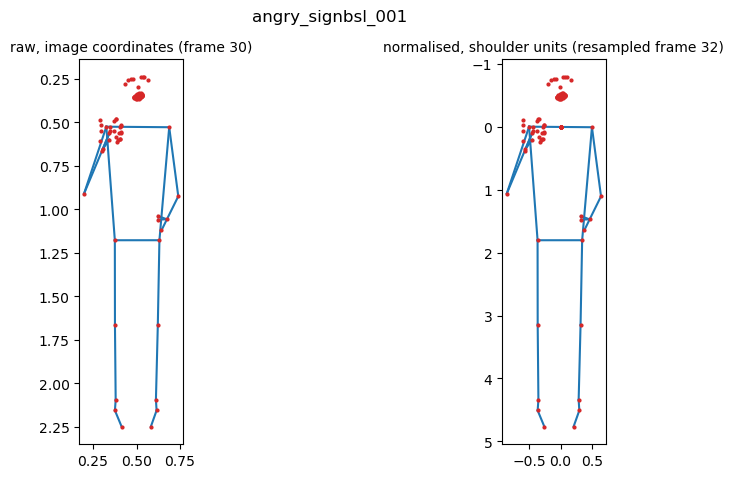

In [11]:
# Skeleton before vs after normalisation. Matplotlib skips NaN points automatically,
# so undetected landmarks simply do not appear in the raw plot.
POSE_CONNECTIONS = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
    (15, 17), (15, 19), (15, 21), (16, 18), (16, 20), (16, 22),
    (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (24, 26), (26, 28),
    (27, 29), (29, 31), (28, 30), (30, 32),
]


def plot_skeleton(ax, frame, title):
    pose = frame[L.POSE_SLICE]
    for i, j in POSE_CONNECTIONS:
        ax.plot([pose[i, 0], pose[j, 0]], [pose[i, 1], pose[j, 1]],
                color="tab:blue", lw=1.5, zorder=2)
    ax.scatter(frame[:, 0], frame[:, 1], s=4, color="tab:red", zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image convention: y grows downwards


mid = raw.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_skeleton(axes[0], raw[mid], f"raw, image coordinates (frame {mid})")
plot_skeleton(axes[1], fixed[32], "normalised, shoulder units (resampled frame 32)")
fig.suptitle(sample_npz.stem)
plt.show()


## 5 — Dataset summary and organisation-grouped splits

CLI: `python -m src.dataset --summary --make-splits`

The train/val split is grouped **by source organisation**: no organisation contributes
clips to both sides, so the model cannot pass validation by memorising a studio's
backdrop, signer or camera style. `make_splits` shuffles organisations deterministically
and greedily fills the validation side towards `val_frac=0.2`, warning if any class ends
up missing from either side.

**`data/splits.json` is committed to the repository on purpose** — the exact partition is
part of the experimental record. The cell below therefore only creates it if it does not
exist yet; the file must be deleted first if regeneration is intended.

In [12]:
metadata = pd.read_csv("data/metadata.csv")

counts = metadata.groupby(metadata["word"].astype(str))["clip_id"].count()
print(f"{len(metadata)} clips, {counts.size} classes, "
      f"{counts.min()}-{counts.max()} clips per class (median {counts.median():.0f})")

metadata.groupby("organisation")["clip_id"].count().sort_values(ascending=False)


293 clips, 50 classes, 4-12 clips per class (median 6)


organisation
signstation                  96
signmonkey                   45
youtube                      39
gpnhs                        27
corpusngt                    26
deafway                      16
nf                           16
signon                       10
exeterdeafacademyvoiceoff     8
bslfirst                      3
winkball                      3
wolver                        2
deafsigns                     1
ict                           1
Name: clip_id, dtype: int64

In [13]:
from src.dataset import make_splits, load_splits

splits_path = Path("data/splits.json")
if splits_path.exists():
    splits = load_splits()  # keep the committed partition
    print("data/splits.json exists - keeping the committed split")
else:
    splits = make_splits("data/metadata.csv", "data/vocabulary.csv",
                         val_frac=0.2, seed=42)
    with open(splits_path, "w", encoding="utf-8") as f:
        json.dump(splits, f, indent=2)
    print(f"wrote {splits_path}")

n_train, n_val = len(splits["train"]), len(splits["val"])
print(f"train {n_train} / val {n_val} clips "
      f"(val fraction {n_val / (n_train + n_val):.2f})")
print("validation organisations:", ", ".join(splits["val_orgs"]))
print(f"{len(splits['label_list'])} classes")


data/splits.json exists - keeping the committed split
train 224 / val 69 clips (val fraction 0.24)
validation organisations: corpusngt, deafway, gpnhs
50 classes


## 6 — `BSLDataset`: from clip ids to training batches

`BSLDataset` (`src/dataset.py`) wraps sections 4 and 7: per item it runs
`load_clip` → *(temporal augmentation if enabled)* → 64-frame resample →
*(spatial augmentation if enabled)* → flatten to a `(64, 315)` float32 tensor.
Class index = position of the clip's word in `label_list`. All DataLoaders in this
project use `num_workers=0` and seeded generators, which is part of the determinism
guarantee.

In [14]:
from torch.utils.data import DataLoader

from src.dataset import BSLDataset, clip_id_to_word

label_list = splits["label_list"]
label_to_idx = {word: i for i, word in enumerate(label_list)}

train_ids = splits["train"]
train_labels = [label_to_idx[clip_id_to_word(c)] for c in train_ids]

train_ds = BSLDataset(train_ids, train_labels, "data/landmarks",
                      augment=True, seq_len=64, seed=42)

features, target = train_ds[0]
print(f"one item : features {tuple(features.shape)} {features.dtype}, "
      f"label {target} ({label_list[target]})")

generator = torch.Generator()
generator.manual_seed(42)
loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0,
                    generator=generator)
xb, yb = next(iter(loader))
print(f"one batch: inputs {tuple(xb.shape)}, targets {tuple(yb.shape)}")


one item : features (64, 315) torch.float32, label 14 (hello)
one batch: inputs (32, 64, 315), targets (32,)


## 7 — Augmentation + visual sanity check

Script: `python scripts/plot_augmentations.py` (writes `results/figures/augmentation_check.png`)

`src/augment.py` provides label-preserving perturbations, each firing independently with
p = 0.5:

- **spatial** (after the 64-frame resample): rotation ±15° in the x-y plane, uniform scale
  0.9–1.1, x-y translation ±0.05, Gaussian jitter σ = 0.01;
- **temporal** (before the resample): speed change ×0.8–1.2 **or** dropping up to 10% of
  frames, never going below 8 frames.

The point of the visual check is to confirm the transforms are big enough to matter but
small enough that the sign stays the same sign.

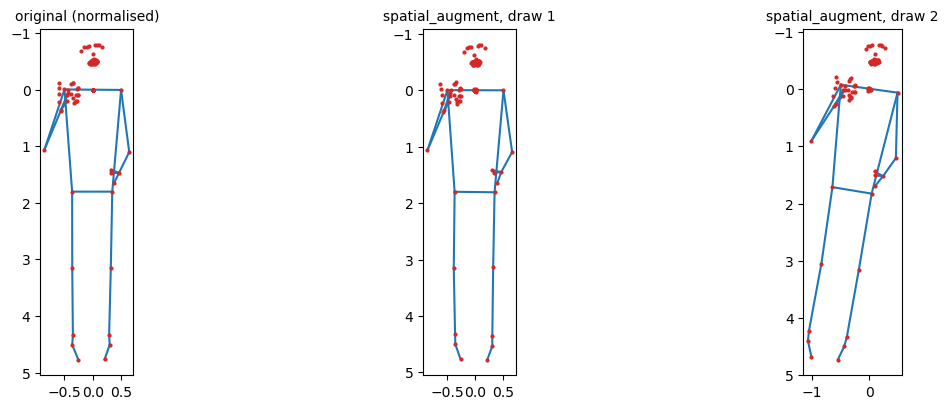

temporal_augment: 60 frames -> 71 frames
temporal_augment: 60 frames -> 70 frames
temporal_augment: 60 frames -> 60 frames
temporal_augment: 60 frames -> 60 frames
temporal_augment: 60 frames -> 60 frames


In [15]:
from src.augment import spatial_augment, temporal_augment

aug_rng = np.random.default_rng(7)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_skeleton(axes[0], fixed[32], "original (normalised)")
for i, ax in enumerate(axes[1:], start=1):
    aug = spatial_augment(fixed, aug_rng)
    plot_skeleton(ax, aug[32], f"spatial_augment, draw {i}")
plt.show()

# Temporal augmentation changes the frame count (it runs BEFORE the 64-frame resample):
for _ in range(5):
    out = temporal_augment(clean, aug_rng)
    print(f"temporal_augment: {clean.shape[0]} frames -> {out.shape[0]} frames")


## 8 — Models: from-scratch transformer vs matched LSTM baseline

CLI: `python -m src.models` (prints parameter counts)

`src/models.py` implements the **pre-LN transformer encoder from scratch** (manual
scaled-dot-product attention — no `nn.Transformer` / `nn.MultiheadAttention`): input
projection → learnable CLS token → learned positional embeddings → 4 encoder layers
(d_model 192, 6 heads, FFN 384) → LayerNorm → linear head on the CLS position. The
baseline is a unidirectional 2×256 LSTM whose final hidden state feeds the same kind of
head. Both map `(B, 64, 315)` to 50-class logits, at deliberately matched capacity (~1M
parameters).

In [16]:
from src.models import build_model, count_parameters

transformer = build_model({"arch": "transformer"})
lstm = build_model({"arch": "lstm"})

t_params = count_parameters(transformer)
l_params = count_parameters(lstm)
print(f"TransformerClassifier: {t_params:,} ({t_params / 1e6:.2f}M)")
print(f"LSTMClassifier:        {l_params:,} ({l_params / 1e6:.2f}M)")
print(f"relative difference |T-L|/T: {abs(t_params - l_params) / t_params:.3f}")

# Shape check: a dummy batch through both models.
dummy = torch.zeros(2, 64, 315)
with torch.inference_mode():
    print(f"\ntransformer(dummy) -> {tuple(transformer(dummy).shape)}")
    print(f"lstm(dummy)        -> {tuple(lstm(dummy).shape)}")


TransformerClassifier: 1,271,474 (1.27M)
LSTMClassifier:        1,125,938 (1.13M)
relative difference |T-L|/T: 0.114

transformer(dummy) -> (2, 50)
lstm(dummy)        -> (2, 50)


## 9 — The 12 experiment configs

CLI: `python configs/gen_configs.py`

Every experiment is one YAML file: {transformer, lstm} × {aug, noaug} × seeds {42, 43, 44}.
All hyperparameters (80 epochs, batch 32, AdamW lr 3e-4, weight decay 0.01, 5 warm-up
epochs then cosine decay, label smoothing 0.1) are identical across the grid — only
architecture, augmentation flag and seed vary. The generator rewrites all 12 files, so individual
files should not be edited by hand; changes belong in the template in
`configs/gen_configs.py`.

In [17]:
%run configs/gen_configs.py


wrote transformer_aug_s42.yaml
wrote transformer_aug_s43.yaml
wrote transformer_aug_s44.yaml
wrote transformer_noaug_s42.yaml
wrote transformer_noaug_s43.yaml
wrote transformer_noaug_s44.yaml
wrote lstm_aug_s42.yaml
wrote lstm_aug_s43.yaml
wrote lstm_aug_s44.yaml
wrote lstm_noaug_s42.yaml
wrote lstm_noaug_s43.yaml
wrote lstm_noaug_s44.yaml


In [18]:
cfg = yaml.safe_load(Path("configs/transformer_aug_s42.yaml").read_text(encoding="utf-8"))
cfg


{'run_id': 'transformer_aug_s42',
 'arch': 'transformer',
 'augment': True,
 'seed': 42,
 'epochs': 80,
 'batch_size': 32,
 'lr': 0.0003,
 'weight_decay': 0.01,
 'warmup_epochs': 5,
 'label_smoothing': 0.1,
 'seq_len': 64,
 'in_dim': 315,
 'n_classes': 50,
 'd_model': 192,
 'n_layers': 4,
 'n_heads': 6,
 'd_ff': 384,
 'dropout': 0.1,
 'lstm_hidden': 256,
 'lstm_layers': 2,
 'landmarks_dir': 'data/landmarks',
 'splits_file': 'data/splits.json',
 'metadata_csv': 'data/metadata.csv',
 'out_dir': 'results/runs'}

## 10 — Sanity checks (run before trusting any result)

CLI: `python -m src.train --config configs/transformer_aug_s42.yaml --overfit-batch`
and `... --shuffle-labels`

- **Overfit one batch** — trains on a single fixed batch with weight decay disabled and
  *asserts* ≥ 95% batch accuracy within 200 steps. Passing proves the model / loss /
  optimiser wiring can learn at all. Writes no files.
- **Label shuffle** — permutes the training labels once (seeded) and trains normally;
  validation accuracy must stay near chance (1/50 = 2%). If it doesn't, labels are leaking
  into the features. The run is written under `{run_id}_shufflelabels` so it never
  clobbers a real run. This is a full training run, hence off by default here.

In [19]:
from src.train import run_training

run_training(dict(cfg), overfit_batch=True)  # asserts >=95% within 200 steps


[train] built transformer model | trainable parameters: 1,271,474
[train] device=cuda | train clips=224 | val clips=69 | augment=True


step  20 | loss 1.6797 | batch acc 0.812
step  24 | loss 1.3852 | batch acc 0.969
overfit-batch PASS: batch acc 0.969 within 24 steps


{'best_val_acc': nan,
 'run_dir': None,
 'overfit_steps': 24,
 'overfit_acc': 0.96875}

In [20]:
RUN_SHUFFLE_LABELS = False  # full 80-epoch run; writes results/runs/transformer_aug_s42_shufflelabels

if RUN_SHUFFLE_LABELS:
    run_training(dict(cfg), shuffle_labels=True)
else:
    print("skipped (RUN_SHUFFLE_LABELS = False)")


skipped (RUN_SHUFFLE_LABELS = False)


## 11 — Training

CLI: `python -m src.train --config configs/transformer_aug_s42.yaml` (and a shell loop
over `configs/*.yaml` for the grid; GPU training uses `notebooks/train_colab.ipynb`)

`run_training` is the programmatic equivalent of the CLI: it seeds everything
(python/numpy/torch, deterministic cuDNN), builds the dataloaders and model, then runs
80 epochs of AdamW + warmup/cosine schedule, logging per-epoch metrics to
`{run_dir}/metrics.csv` and checkpointing the best-by-validation-accuracy model to
`{run_dir}/best.pt`, alongside a copy of the config and an `env.txt` (versions + git
commit) for reproducibility.

**Careful:** with `QUICK_DEMO = False` the cell below re-runs the real 80-epoch run and
**overwrites `results/runs/transformer_aug_s42/`**. The default writes a short smoke run
to a separate directory instead.

In [21]:
QUICK_DEMO = True  # True: 2-epoch smoke run into results/notebook_demo; False: the real thing

train_cfg = dict(cfg)
if QUICK_DEMO:
    train_cfg.update(epochs=2, run_id="notebook_demo_transformer",
                     out_dir="results/notebook_demo")

result = run_training(train_cfg, device="cpu")
print(f"\nbest val acc {result['best_val_acc']:.4f} "
      f"at epoch {result['best_epoch']} -> {result['run_dir']}")


[train] built transformer model | trainable parameters: 1,271,474
[train] device=cpu | train clips=224 | val clips=69 | augment=True


epoch 1:   0%|          | 0/7 [00:00<?, ?it/s]

epoch 1:  14%|█▍        | 1/7 [00:00<00:01,  5.46it/s]

epoch 1:  29%|██▊       | 2/7 [00:00<00:00,  5.84it/s]

epoch 1:  43%|████▎     | 3/7 [00:00<00:00,  6.04it/s]

...

epoch 2:  57%|█████▋    | 4/7 [00:00<00:00,  6.12it/s]

epoch 2:  71%|███████▏  | 5/7 [00:00<00:00,  6.13it/s]

epoch 2:  86%|████████▌ | 6/7 [00:00<00:00,  6.02it/s]

epoch 2: 100%|██████████| 7/7 [00:01<00:00,  5.96it/s]

epoch   2/2 | train loss 3.9354 acc 0.0312 | val loss 4.0481 acc 0.0290 | lr 1.20e-04
[train] done: best val acc 0.0290 at epoch 2 | run dir: results\notebook_demo\notebook_demo_transformer

best val acc 0.0290 at epoch 2 -> results\notebook_demo\notebook_demo_transformer


In [22]:
# The full 12-run grid — equivalent of looping `python -m src.train --config` over
# configs/*.yaml. Hours on CPU, and it OVERWRITES the finished runs in results/runs/.
RUN_FULL_GRID = False

if RUN_FULL_GRID:
    for cfg_path in sorted(Path("configs").glob("*.yaml")):
        print(f"=== {cfg_path.name} ===")
        run_training(yaml.safe_load(cfg_path.read_text(encoding="utf-8")))
else:
    done = sorted(p.parent.name for p in Path("results/runs").glob("*/best.pt"))
    print(f"skipped (RUN_FULL_GRID = False) - {len(done)} finished runs on disk:")
    for name in done:
        print(" ", name)


skipped (RUN_FULL_GRID = False) - 13 finished runs on disk:
  lstm_aug_s42
  lstm_aug_s43
  lstm_aug_s44
  lstm_noaug_s42
  lstm_noaug_s43
  lstm_noaug_s44
  transformer_aug_s42
  transformer_aug_s42_shufflelabels
  transformer_aug_s43
  transformer_aug_s44
  transformer_noaug_s42
  transformer_noaug_s43
  transformer_noaug_s44


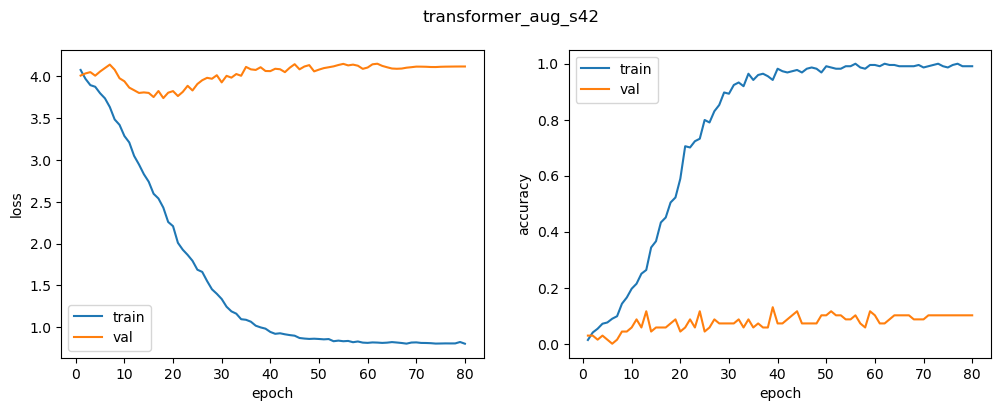

best val acc: 0.1304 at epoch 39


In [23]:
# Training curves of a finished run, straight from its metrics.csv.
metrics_csv = Path("results/runs/transformer_aug_s42/metrics.csv")
m = pd.read_csv(metrics_csv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(m["epoch"], m["train_loss"], label="train")
axes[0].plot(m["epoch"], m["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[1].plot(m["epoch"], m["train_acc"], label="train")
axes[1].plot(m["epoch"], m["val_acc"], label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
fig.suptitle(metrics_csv.parent.name)
plt.show()

print(f"best val acc: {m['val_acc'].max():.4f} at epoch {m['val_acc'].idxmax() + 1}")


## 12 — Hyperparameter selection: the lr / weight-decay grid

Script: `python scripts/run_lr_grid.py`

Before the 12-run grid was launched, learning rate and weight decay were chosen on
validation only: {3e-4, 1e-3} × {0.01, 0.05}, one run per architecture, seed 42 with
augmentation, written under `results/lr_grid/`. The winners were frozen into the
experiment configs. The test set is never touched here. This is 8 full training runs,
so it is off by default — the summary of the finished runs on disk is shown instead.

In [24]:
RUN_LR_GRID = False  # 8 x 80-epoch runs

if RUN_LR_GRID:
    for arch in ("transformer", "lstm"):
        base = yaml.safe_load(
            Path(f"configs/{arch}_aug_s42.yaml").read_text(encoding="utf-8"))
        for lr in (3e-4, 1e-3):
            for wd in (0.01, 0.05):
                grid_cfg = dict(base)
                grid_cfg.update(lr=lr, weight_decay=wd,
                                run_id=f"{arch}_lr{lr:g}_wd{wd:g}",
                                out_dir="results/lr_grid")
                out = run_training(grid_cfg)
                print(f"[lr-grid] {arch} lr={lr:g} wd={wd:g} "
                      f"-> best val acc {out['best_val_acc']:.4f}")
else:
    rows = []
    for run_dir in sorted(Path("results/lr_grid").glob("*")):
        mcsv = run_dir / "metrics.csv"
        if mcsv.exists():
            rows.append({"run": run_dir.name,
                         "best_val_acc": pd.read_csv(mcsv)["val_acc"].max()})
    if rows:
        display(pd.DataFrame(rows).sort_values("best_val_acc", ascending=False))
    else:
        print("no finished lr-grid runs found under results/lr_grid/")


,run,best_val_acc
4,transformer_lr0.0003_wd0.01,0.130435
5,transformer_lr0.0003_wd0.05,0.130435
7,transformer_lr0.001_wd0.05,0.130435
6,transformer_lr0.001_wd0.01,0.115942
0,lstm_lr0.0003_wd0.01,0.043478
1,lstm_lr0.0003_wd0.05,0.043478
2,lstm_lr0.001_wd0.01,0.043478
3,lstm_lr0.001_wd0.05,0.043478


## 13 — Evaluation, run comparison, and McNemar's test

CLI: `python -m src.evaluate --checkpoint results/runs/<run>/best.pt --split val`

`run_evaluation` loads a checkpoint (architecture and label list travel inside `best.pt`),
runs the validation clips through the exact same preprocessing as training (no
augmentation), and writes four artefacts into `{run_dir}/eval_val/`: `predictions.csv`
(with top-5 columns), `per_class_accuracy.csv`, `confusion_matrix.csv` and
`confusion_matrix.png`. It reports top-1 / top-5 accuracy and macro-F1.

In [25]:
from src.evaluate import run_evaluation

eval_metrics = run_evaluation("results/runs/transformer_aug_s42/best.pt", "val")


C:\Users\shamr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\shamr\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\shamr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\shamr\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes 

Evaluated 69 clips from split 'val' (data/landmarks)
  top-1 accuracy : 0.1304
  top-5 accuracy : 0.3768
  macro-F1       : 0.0853
Outputs written to C:\Users\shamr\Downloads\Claude\MSc Project\CODE\bsl-word-transformer\results\runs\transformer_aug_s42\eval_val


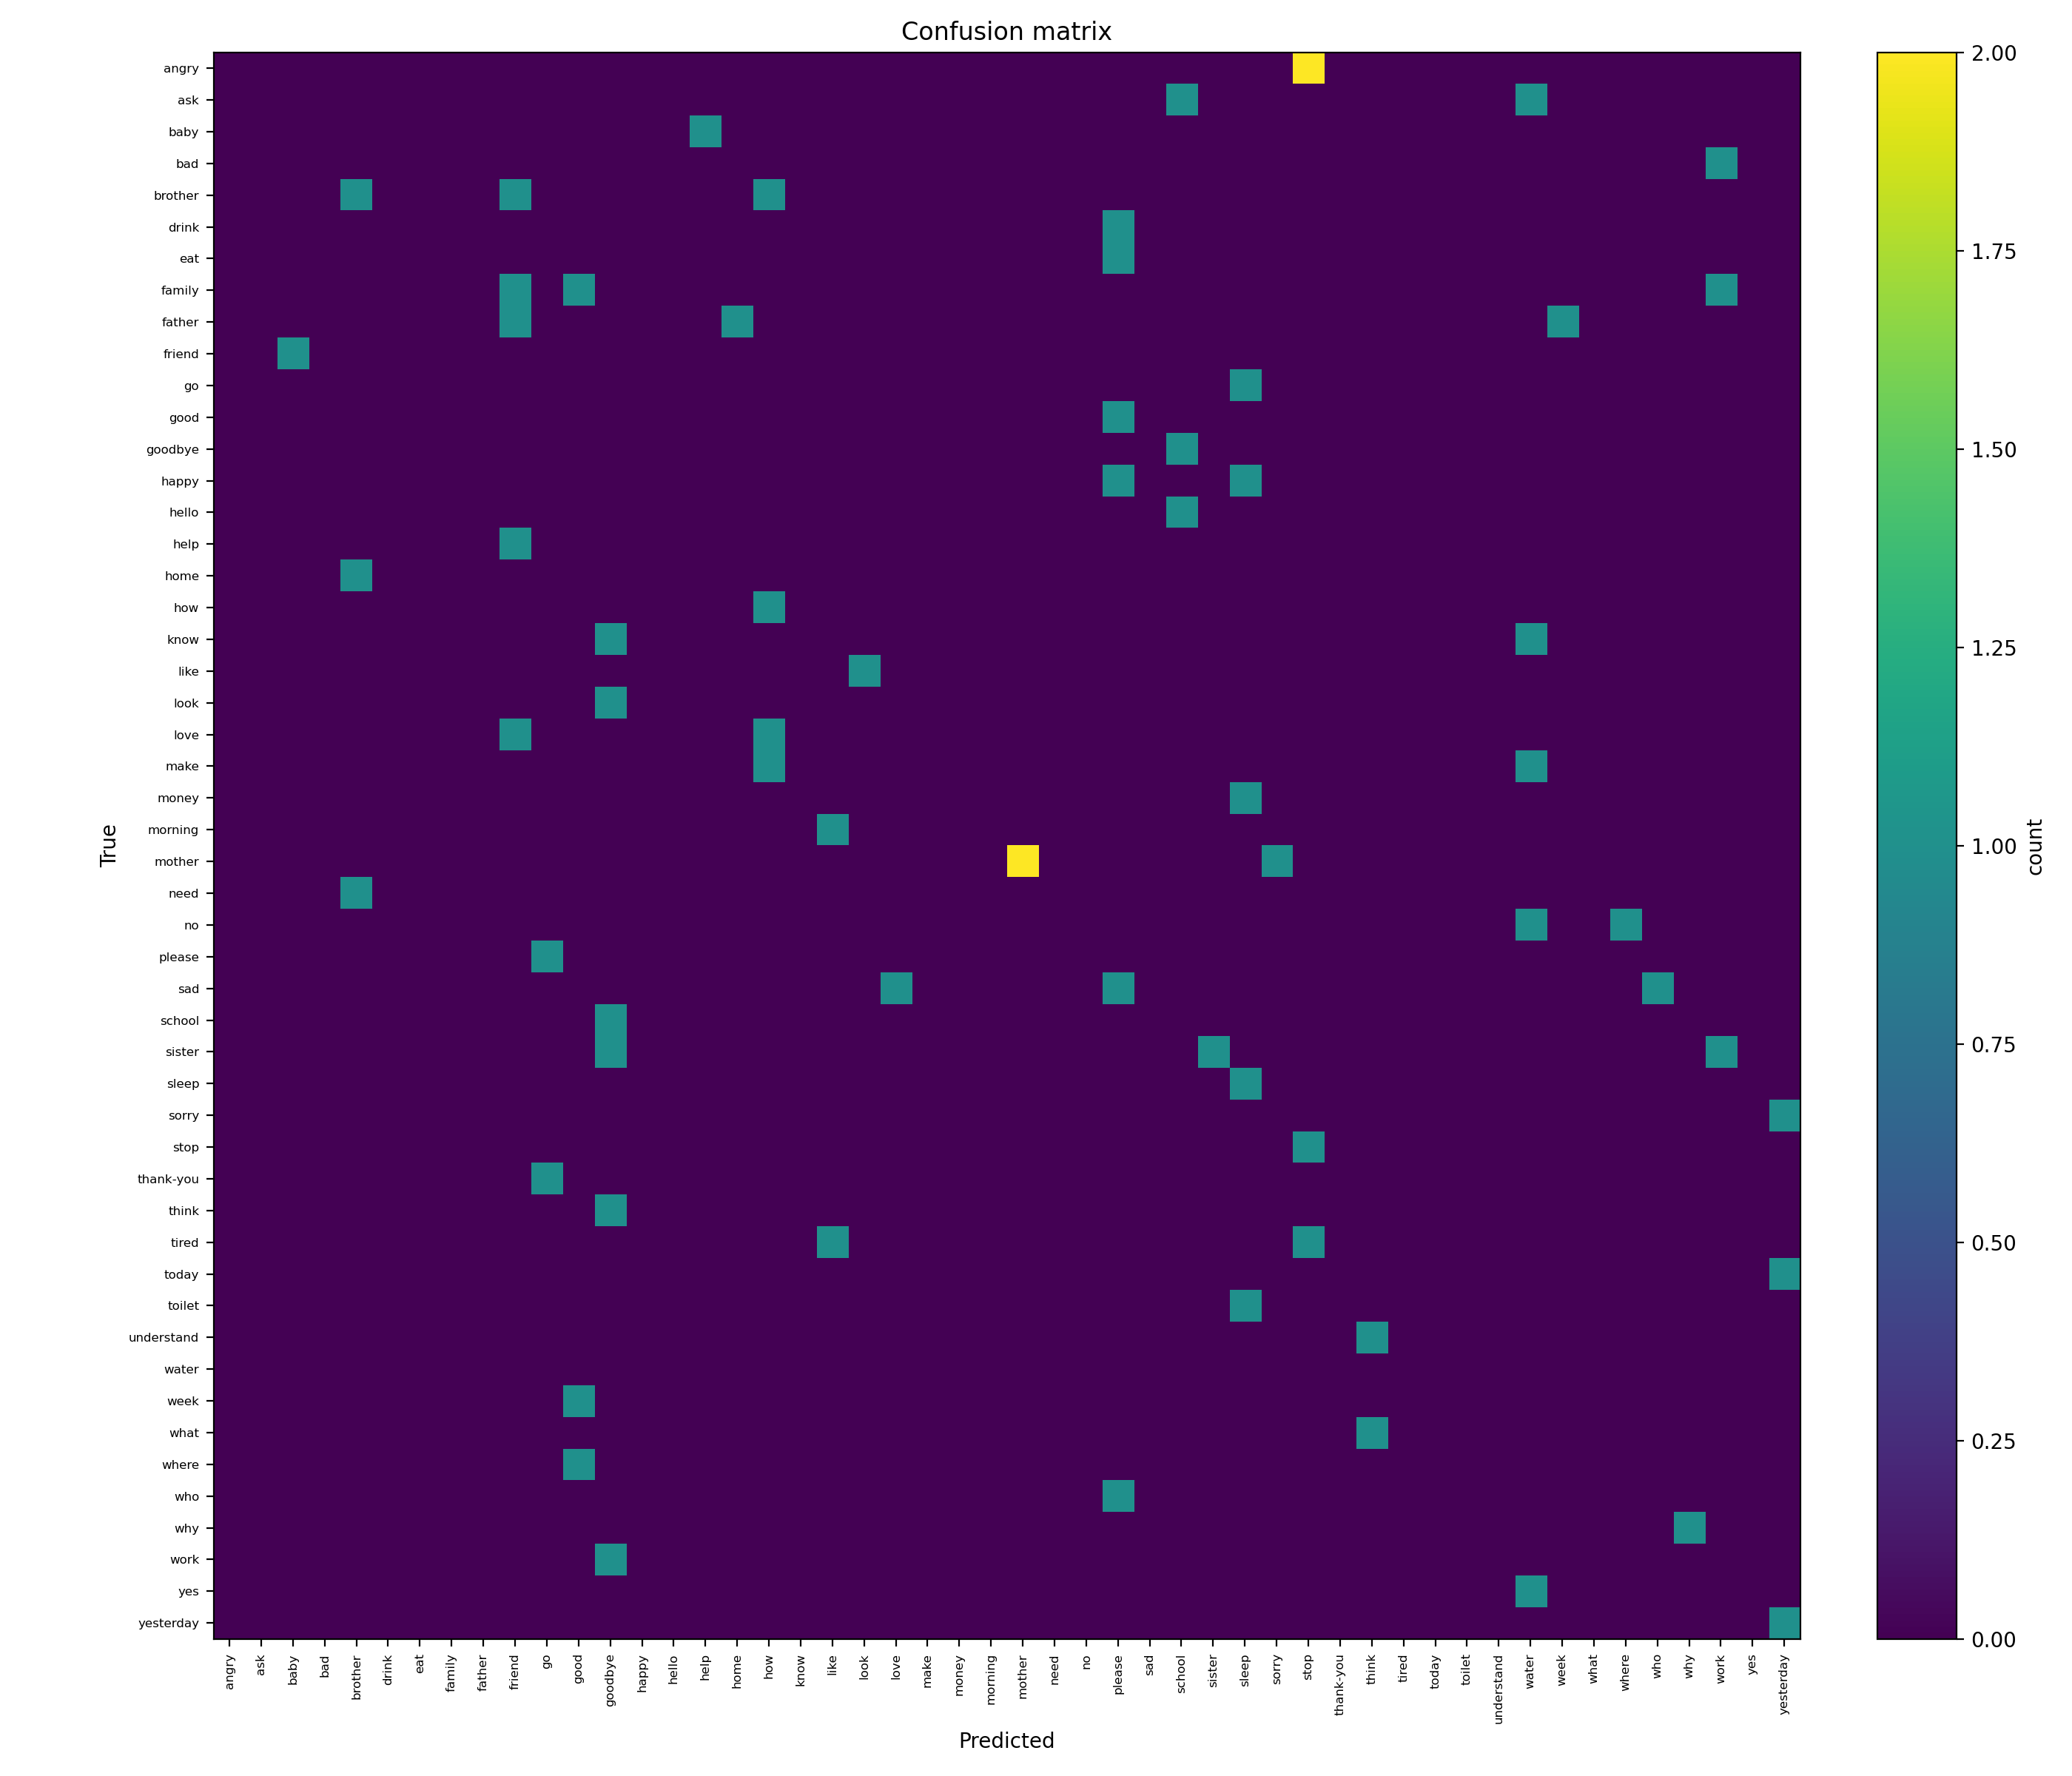

hardest classes on validation:


,word,n,correct,accuracy
0,angry,2,0,0.0
48,yes,1,0,0.0
26,need,1,0,0.0
27,no,2,0,0.0
28,please,1,0,0.0
29,sad,3,0,0.0
30,school,1,0,0.0
33,sorry,1,0,0.0
35,thank-you,1,0,0.0
23,money,1,0,0.0


In [26]:
from IPython.display import Image, display

out_dir = Path(eval_metrics["out_dir"])
display(Image(filename=str(out_dir / "confusion_matrix.png"), width=700))

per_class = pd.read_csv(out_dir / "per_class_accuracy.csv")
print("hardest classes on validation:")
per_class.sort_values("accuracy").head(10)


In [27]:
# Best validation accuracy of every finished run, as mean +- std per condition
# (the dissertation reports results over seeds 42/43/44).
rows = []
for run_dir in sorted(Path("results/runs").glob("*")):
    mcsv = run_dir / "metrics.csv"
    parts = run_dir.name.rsplit("_", 2)
    if not mcsv.exists() or len(parts) != 3 or run_dir.name.endswith("_shufflelabels"):
        continue
    arch, aug, seed = parts
    rows.append({"run": run_dir.name, "arch": arch, "augmentation": aug, "seed": seed,
                 "best_val_acc": pd.read_csv(mcsv)["val_acc"].max()})
runs_df = pd.DataFrame(rows)
display(runs_df.sort_values("best_val_acc", ascending=False))
runs_df.groupby(["arch", "augmentation"])["best_val_acc"].agg(["mean", "std", "count"])


,run,arch,augmentation,seed,best_val_acc
11,transformer_noaug_s44,transformer,noaug,s44,0.173913
6,transformer_aug_s42,transformer,aug,s42,0.130435
8,transformer_aug_s44,transformer,aug,s44,0.130435
9,transformer_noaug_s42,transformer,noaug,s42,0.130435
10,transformer_noaug_s43,transformer,noaug,s43,0.130435
7,transformer_aug_s43,transformer,aug,s43,0.101449
5,lstm_noaug_s44,lstm,noaug,s44,0.072464
1,lstm_aug_s43,lstm,aug,s43,0.057971
0,lstm_aug_s42,lstm,aug,s42,0.043478
2,lstm_aug_s44,lstm,aug,s44,0.043478


mean       std  count
arch        augmentation                           
lstm        aug           0.048309  0.008368      3
            noaug         0.048309  0.022138      3
transformer aug           0.120773  0.016735      3
            noaug         0.144928  0.025102      3

In [28]:
# McNemar's test: are two models' error patterns significantly different on the SAME clips?
# CLI: python -m src.evaluate --mcnemar runA/eval_val/predictions.csv runB/eval_val/predictions.csv
from src.evaluate import run_mcnemar

pair = ("transformer_aug_s42", "lstm_aug_s42")
for run in pair:  # make sure both runs have validation predictions
    if not Path(f"results/runs/{run}/eval_val/predictions.csv").exists():
        run_evaluation(f"results/runs/{run}/best.pt", "val")

mcnemar_result = run_mcnemar(
    f"results/runs/{pair[0]}/eval_val/predictions.csv",
    f"results/runs/{pair[1]}/eval_val/predictions.csv",
)


McNemar's test on paired predictions
  A: results/runs/transformer_aug_s42/eval_val/predictions.csv  (accuracy 0.1304)
  B: results/runs/lstm_aug_s42/eval_val/predictions.csv  (accuracy 0.0435)
  aligned pairs           : 69
  b (A right, B wrong)    : 7
  c (A wrong, B right)    : 1
  exact binomial p-value  : 0.0703125
  chi2 (continuity corr.) : 3.1250, p = 0.0770999
Verdict: NO significant difference at alpha=0.05 (exact test)


### One-shot test evaluation — superseded by section 18

The originally planned self-recorded test set was **replaced on 2026-07-27** by
the re-sourced held-out evaluation in **section 18**: an
organisation-held-out one-shot test plus a BSL SignBank cross-corpus test. The guarded
cell below is kept only as the CLI reference; the executed one-shot results live in
`results/runs_v2/<run>/eval_test_orgheldout/` and `eval_test_signbank/`.

In [29]:
RUN_TEST_EVAL = False  # one shot only - see the note above

if RUN_TEST_EVAL:
    best_run = "transformer_aug_s42"  # <- set to the model selected on validation
    run_evaluation(f"results/runs/{best_run}/best.pt", "test")
else:
    print("skipped (RUN_TEST_EVAL = False)")


skipped (RUN_TEST_EVAL = False)


## 14 — Latency benchmark

CLI: `python -m src.benchmark --checkpoint ... --synthetic --frames 1000 --stride 8`
(or `--webcam 0` / `--video clip.mp4` for the full pipeline including MediaPipe)

Times every stage (capture, holistic, normalise, forward) with `perf_counter`, reports
medians and 95th percentiles after warm-up, and checks the real-time criteria:
**≥ 15 fps end-to-end** and **< 100 ms median per-window classification**. One row per
run is appended to `results/latency.csv`. `--synthetic` feeds random landmark frames so
it runs without a camera or mediapipe — the numbers then cover normalise + forward only.

In [30]:
from src.benchmark import run_benchmark

bench_row = run_benchmark("results/runs/transformer_aug_s42/best.pt",
                          mode="synthetic", frames=300, stride=8)


Benchmark: mode=synthetic frames=300 stride=8 seq_len=64 (warmup 32 frames excluded)
Stage timings (ms):
  capture    skipped (synthetic mode)
  holistic   skipped (synthetic mode)
  normalise  median    0.019   p95    0.036   (n=300)
  forward    median    1.305   p95    1.410   (n=34)
End-to-end: 300 frames in 0.05 s -> 5737.5 fps (synthetic: capture+holistic skipped)
Per-window classification: median 1.30 ms, p95 1.41 ms over 34 windows
PASS: end-to-end throughput 5737.5 fps vs target >= 15 fps
PASS: per-window latency median 1.30 ms vs target < 100 ms
Row appended to results\latency.csv


In [31]:
# Full-pipeline benchmark against the webcam (needs a camera + mediapipe):
RUN_WEBCAM_BENCH = False

if RUN_WEBCAM_BENCH:
    run_benchmark("results/runs/transformer_aug_s42/best.pt",
                  mode="webcam", source=0, frames=1000, stride=8)
else:
    print("skipped (RUN_WEBCAM_BENCH = False)")


skipped (RUN_WEBCAM_BENCH = False)


## 15 — Real-time webcam demo

CLI: `python -m src.realtime --checkpoint results/runs/<run>/best.pt`

The live loop keeps a rolling buffer of the last **64 normalised frames**, classifies
every **8 frames**, and only displays a prediction once the same top-1 class has cleared a
**0.6 confidence threshold for 3 consecutive windows** (the `PredictionSmoother`). It
opens a native OpenCV window, so it works from a *local* Jupyter server but not from a
remote/hosted one — press `q` in the window to quit.

The smoother is worth understanding on its own, so the first cell drives it with a
scripted confidence sequence.

In [32]:
from src.realtime import PredictionSmoother

smoother = PredictionSmoother(threshold=0.6, consecutive=3)
scripted = [(4, 0.9), (4, 0.8), (7, 0.7), (7, 0.9), (7, 0.85),  # 7 confirmed on the 3rd
            (2, 0.4), (2, 0.95), (2, 0.9)]                       # low conf resets the streak
for cls, conf in scripted:
    confirmed, c = smoother.update(cls, conf)
    shown = f"class {confirmed} ({c:.2f})" if confirmed is not None else "listening..."
    print(f"window top-1 = class {cls} @ {conf:.2f}  ->  displayed: {shown}")


window top-1 = class 4 @ 0.90  ->  displayed: listening...
window top-1 = class 4 @ 0.80  ->  displayed: listening...
window top-1 = class 7 @ 0.70  ->  displayed: listening...
window top-1 = class 7 @ 0.90  ->  displayed: listening...
window top-1 = class 7 @ 0.85  ->  displayed: class 7 (0.85)
window top-1 = class 2 @ 0.40  ->  displayed: class 7 (0.85)
window top-1 = class 2 @ 0.95  ->  displayed: class 7 (0.85)
window top-1 = class 2 @ 0.90  ->  displayed: class 7 (0.85)


In [33]:
RUN_REALTIME = False  # opens an OpenCV window; local Jupyter only; press q to quit

if RUN_REALTIME:
    from src.realtime import run as realtime_run

    realtime_run("results/runs/transformer_aug_s42/best.pt",
                 camera=0, stride=8, threshold=0.6, consecutive=3)
else:
    print("skipped (RUN_REALTIME = False)")


skipped (RUN_REALTIME = False)


## 16 — Gradio demo app

CLI: `python app/app.py`

Upload or webcam-record a 2–3 second clip of a single sign; the app runs MediaPipe
extraction plus the shared preprocessing pipeline and shows the top-5 predictions.
The checkpoint is resolved from the `BSL_CHECKPOINT` env var, then `app/model/best.pt`,
then the newest `results/runs/*/best.pt`. Launched from a notebook, Gradio renders the
interface inline. It is a research demonstrator for learning and lookup — **not an
interpreting service**.

In [34]:
RUN_APP = False  # needs gradio + mediapipe; serves on a local port until stopped

if RUN_APP:
    import importlib.util

    spec = importlib.util.spec_from_file_location("bsl_app",
                                                  str(REPO_ROOT / "app" / "app.py"))
    bsl_app = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(bsl_app)  # builds `demo` at import time
    bsl_app.demo.queue(max_size=8).launch(inline=True)
    # later: bsl_app.demo.close()
else:
    print("skipped (RUN_APP = False)")


skipped (RUN_APP = False)


## 17 — Test suite

CLI: `pytest`

The pytest suite covers the model shapes and parameter counts, normalisation invariances,
augmentation bounds, dataset/resampling behaviour, evaluation metrics and a training smoke
test — and it deliberately runs **without any data downloaded and without mediapipe**, so
it works on any machine as a first sanity check.

In [35]:
!pytest -q


'pytest' is not recognized as an internal or external command,
operable program or batch file.


## 18 — v2 partition: the re-sourced held-out evaluation (2026-07-27)

The originally planned self-recorded test set was replaced on
2026-07-27 by a **two-part re-sourced held-out evaluation**:

1. **Organisation-held-out one-shot test** — the three v1 validation organisations
   (*corpusngt, deafway, gpnhs*; 69 clips, 49/50 classes), which no model was ever
   trained on, become the test partition. Model selection moves to a new clip-stratified
   validation split (exactly one clip per word, seeded) inside the eleven training
   organisations, and the 12-run grid is **re-trained** against it
   (`data/splits_v2.json`, `configs_v2/`, `results/runs_v2/`,
   derivation: `src/make_v2_partition.py`), so no selected model ever used test clips
   for selection. Organisation grouping is the methodology's signer proxy, so this
   preserves source/signer-independent evaluation.
2. **BSL SignBank cross-corpus one-shot test** — 100 citation-form clips of Deaf signers
   from an entirely unrelated corpus (next subsection).

Disclosed caveats: learning rate and weight decay were frozen
in the Chapter-3 grid using the former validation organisations, so the promoted test
partition influenced *hyperparameter* (never model-weight) selection; *water* has no
clips in partition 1 and is covered by partition 2 only; the v2 validation split shares
organisations with train and is a model-selection split, not a generalisation estimate.

**GPU note:** `run_training` auto-selects CUDA when available — the v2 grid takes
~10 minutes on a laptop GPU (exact library versions per run are in each run's `env.txt`).
Sanity gates re-run for v2: overfit-batch **PASS** (0.969 in 26 steps); label-shuffle
val acc **0.020 = chance** (`results/runs_v2/transformer_aug_s42_shufflelabels`).

In [36]:
from src.make_v2_partition import main as make_v2_main

if Path("data/splits_v2.json").exists():
    v2 = json.loads(Path("data/splits_v2.json").read_text(encoding="utf-8"))
    print("data/splits_v2.json exists - keeping the committed partition")
    print(f"train {len(v2['train'])} / val {len(v2['val'])} / test {len(v2['test'])} clips; "
          f"test orgs: {', '.join(v2['test_orgs'])}")
else:
    make_v2_main()  # writes splits_v2.json, data/test_landmarks/, configs_v2/

data/splits_v2.json exists - keeping the committed partition
train 174 / val 50 / test 69 clips; test orgs: corpusngt, deafway, gpnhs


In [37]:
RUN_FULL_GRID_V2 = False  # ~10 min on GPU / ~1 h on CPU; OVERWRITES results/runs_v2/

if RUN_FULL_GRID_V2:
    for cfg_path in sorted(Path("configs_v2").glob("*.yaml")):
        print(f"=== {cfg_path.name} ===")
        run_training(yaml.safe_load(cfg_path.read_text(encoding="utf-8")))
else:
    done = sorted(p.parent.name for p in Path("results/runs_v2").glob("*/best.pt"))
    print(f"skipped (RUN_FULL_GRID_V2 = False) - {len(done)} finished v2 runs on disk:")
    for name in done:
        print(" ", name)

skipped (RUN_FULL_GRID_V2 = False) - 13 finished v2 runs on disk:
  lstm_aug_s42
  lstm_aug_s43
  lstm_aug_s44
  lstm_noaug_s42
  lstm_noaug_s43
  lstm_noaug_s44
  transformer_aug_s42
  transformer_aug_s42_shufflelabels
  transformer_aug_s43
  transformer_aug_s44
  transformer_noaug_s42
  transformer_noaug_s43
  transformer_noaug_s44


In [38]:
# Per-run best val acc, per-group mean±std, and the frozen per-group selection.
# Writes results/validation_summary_v2.csv.
%run scripts/summarise_v2.py

wrote results\validation_summary_v2.csv (12 runs)

group                      mean    std  best run (val acc, epoch)
lstm_noaug                0.093  0.009  lstm_noaug_s42 (0.100, ep 33)
lstm_aug                  0.107  0.019  lstm_aug_s42 (0.120, ep 31)
transformer_noaug         0.173  0.019  transformer_noaug_s42 (0.200, ep 34)
transformer_aug           0.160  0.016  transformer_aug_s42 (0.180, ep 32)


### The SignBank cross-corpus test set

CLI: `python -m src.download_signbank --manifest data/signbank_gloss_map_curated.csv`

100 isolated citation-form clips (all 50 words, up to 3 regional variants each) from
**UCL BSL SignBank** (bslsignbank.ucl.ac.uk) — a corpus of Deaf signers entirely disjoint
from the 14 SignBSL contributing organisations, downloaded for **non-commercial
academic research** and used solely as a held-out evaluation
set, never redistributed.

Provenance chain, all committed:
- `data/signbank_gloss_map.csv` — the full 103-row word→gloss→video mapping built from
  SignBank's search UI, with per-row match confidence and sense notes;
- `data/signbank_gloss_map_curated.csv` — 100 rows after curation: no video file may
  serve two labels (WAVE-HAND stays with *goodbye*, WHAT with *what*) and one
  unverifiable entry (*ask* → gloss TOUCH) removed;
- `data/signbank_metadata.csv` — per-file download record (URL, date, bytes).

Four words carry a **sense flag** (SignBank has no same-gloss entry): *stop*=FINISH,
*today*=NOW, *need*=WANT, *goodbye*=WAVE-HAND — results are reported with and without
them (see the subset analysis below). Extraction reuses section 2's pipeline; hand
dropout on this studio material is only ~2.3%.

In [39]:
RUN_SIGNBANK_DOWNLOAD = False  # polite sequential downloads; for non-commercial academic research use
RUN_SIGNBANK_EXTRACT = False   # mediapipe 0.10.9; ~1.5 s per clip

if RUN_SIGNBANK_DOWNLOAD:
    !{sys.executable} -m src.download_signbank --manifest data/signbank_gloss_map_curated.csv --max-per-word 3
if RUN_SIGNBANK_EXTRACT:
    !{sys.executable} -m src.extract --videos data/test_videos_signbank --out data/test_landmarks_signbank

n_mp4 = len(list(Path("data/test_videos_signbank").glob("*/*.mp4")))
n_npz = len(list(Path("data/test_landmarks_signbank").glob("*/*.npz")))
print(f"on disk: {n_mp4} SignBank mp4s, {n_npz} extracted landmark files")

on disk: 100 SignBank mp4s, 100 extracted landmark files


### One-shot discipline for the v2 tests

Both v2 test partitions were evaluated **exactly once per finally-selected model** on
2026-07-27, after selection was frozen on the v2 validation split. The evaluate CLI
writes to `eval_test/`, which was renamed after each pass so both evaluations coexist:

- `results/runs_v2/<run>/eval_test_orgheldout/` — organisation-held-out test (69 clips)
- `results/runs_v2/<run>/eval_test_signbank/` — SignBank cross-corpus test (100 clips)

Re-running the model on either test set would break the one-shot protocol, so the cells
below only **read the saved predictions** and re-derive the reported numbers from them.
CLI equivalents of the original one-shot runs (do not re-run):

```
python -m src.evaluate --checkpoint results/runs_v2/<run>/best.pt --split test
python -m src.evaluate --checkpoint results/runs_v2/<run>/best.pt --split test --landmarks-dir data/test_landmarks_signbank
python -m src.evaluate --mcnemar <predsA.csv> <predsB.csv>
```

In [40]:
# Summary of the executed one-shot results, recomputed from the saved predictions.csv
# files (reading saved predictions does NOT re-run any model, so it is always safe).
SELECTED = ["transformer_noaug_s42", "transformer_aug_s42", "lstm_aug_s42", "lstm_noaug_s42"]


def test_summary(eval_name):
    rows = []
    for run in SELECTED:
        p = Path(f"results/runs_v2/{run}/{eval_name}/predictions.csv")
        if not p.exists():
            continue
        df = pd.read_csv(p)
        top5_cols = [f"top5_{i}" for i in range(1, 6)]
        top5 = df.apply(lambda r: r["true"] in [r[c] for c in top5_cols], axis=1)
        rows.append({"run": run, "n": len(df),
                     "top1": df["correct"].mean(), "top5": top5.mean()})
    return pd.DataFrame(rows)


print("organisation-held-out test (69 clips, 3 unseen organisations):")
display(test_summary("eval_test_orgheldout"))
print("SignBank cross-corpus test (100 clips, 50/50 words):")
display(test_summary("eval_test_signbank"))

from src.evaluate import run_mcnemar

print("\nMcNemar, organisation-held-out (best transformer vs best LSTM):")
run_mcnemar("results/runs_v2/transformer_noaug_s42/eval_test_orgheldout/predictions.csv",
            "results/runs_v2/lstm_aug_s42/eval_test_orgheldout/predictions.csv")
print("\nMcNemar, SignBank cross-corpus:")
run_mcnemar("results/runs_v2/transformer_noaug_s42/eval_test_signbank/predictions.csv",
            "results/runs_v2/lstm_aug_s42/eval_test_signbank/predictions.csv")

organisation-held-out test (69 clips, 3 unseen organisations):


,run,n,top1,top5
0,transformer_noaug_s42,69,0.130435,0.260870
1,transformer_aug_s42,69,0.086957,0.260870
2,lstm_aug_s42,69,0.014493,0.115942
3,lstm_noaug_s42,69,0.014493,0.159420


SignBank cross-corpus test (100 clips, 50/50 words):


,run,n,top1,top5
0,transformer_noaug_s42,100,0.14,0.31
1,transformer_aug_s42,100,0.14,0.29
2,lstm_aug_s42,100,0.06,0.22
3,lstm_noaug_s42,100,0.05,0.16



McNemar, organisation-held-out (best transformer vs best LSTM):


McNemar's test on paired predictions
  A: results/runs_v2/transformer_noaug_s42/eval_test_orgheldout/predictions.csv  (accuracy 0.1304)
  B: results/runs_v2/lstm_aug_s42/eval_test_orgheldout/predictions.csv  (accuracy 0.0145)
  aligned pairs           : 69
  b (A right, B wrong)    : 9
  c (A wrong, B right)    : 1
  exact binomial p-value  : 0.0214844
  chi2 (continuity corr.) : 4.9000, p = 0.0268567
Verdict: SIGNIFICANT difference at alpha=0.05 (exact test)

McNemar, SignBank cross-corpus:
McNemar's test on paired predictions
  A: results/runs_v2/transformer_noaug_s42/eval_test_signbank/predictions.csv  (accuracy 0.1400)
  B: results/runs_v2/lstm_aug_s42/eval_test_signbank/predictions.csv  (accuracy 0.0600)
  aligned pairs           : 100
  b (A right, B wrong)    : 9
  c (A wrong, B right)    : 1
  exact binomial p-value  : 0.0214844
  chi2 (continuity corr.) : 4.9000, p = 0.0268567
Verdict: SIGNIFICANT difference at alpha=0.05 (exact test)


{'b': 9,
 'c': 1,
 'n_discordant': 10,
 'exact_p': 0.021484375,
 'chi2_stat': 4.9,
 'chi2_p': 0.02685669550752441}

In [41]:
# Sense-variant analysis: overall vs exact-keyword-match (high-confidence) subset,
# and excluding the four words where SignBank has no same-gloss entry.
%run scripts/signbank_subset.py

transformer_noaug_s42:
  all rows      n=100  top1=0.1400  top5=0.3100
  high-conf     n= 76  top1=0.1711  top5=0.3421
  excl flagged  n= 94  top1=0.1383
transformer_aug_s42:
  all rows      n=100  top1=0.1400  top5=0.2900
  high-conf     n= 76  top1=0.1579  top5=0.3158
  excl flagged  n= 94  top1=0.1383
lstm_aug_s42:
  all rows      n=100  top1=0.0600  top5=0.2200
  high-conf     n= 76  top1=0.0789  top5=0.2500
  excl flagged  n= 94  top1=0.0638
lstm_noaug_s42:
  all rows      n=100  top1=0.0500  top5=0.1600
  high-conf     n= 76  top1=0.0658  top5=0.2105
  excl flagged  n= 94  top1=0.0532


## Where to go next

- **`notebooks/eda.ipynb`** — exploratory data analysis: clip counts, durations vs the
  64-frame budget, hand-dropout by source, skeleton overlays, organisation distribution.
- **`notebooks/results.ipynb`** — regenerates every dissertation figure and table from
  `results/runs/*`.
- the **README's *Reproducibility* section** — why each pipeline
  choice was made, and the guarantees (pinned versions, seeded runs, committed split,
  one-shot test discipline) this notebook relies on.